# Lab work 1. Input & output analysis. KNN. Decision tree. Random forest.

## Importing the required libraries

In [1]:
# Importing necessary libraries
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# KNN, Decision tree, Random Forest algorithms
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model performance evaluation imports
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_score, f1_score, recall_score, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

# To ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
# Reading the dataset
data = pd.read_csv('apartments.csv')
df = data.copy()

In [3]:
# Print the first 5 rows with columns as rows for quick overview of the data
df.head().T

,0,1,2,3,4
id,5668640009,5668639818,5668639686,5668639659,5668639374
category,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment,housing/rent/apartment
title,One BR 507 & 509 Esplanade,Three BR 146 Lochview Drive,Three BR 3101 Morningside Drive,Two BR 209 Aegean Way,One BR 4805 Marquette NE
body,"This unit is located at 507 & 509 Esplanade, R...","This unit is located at 146 Lochview Drive, Ne...",This unit is located at 3101 Morningside Drive...,"This unit is located at 209 Aegean Way, Vacavi...","This unit is located at 4805 Marquette NE, Alb..."
amenities,NaN,NaN,NaN,NaN,NaN
bathrooms,1.0,1.5,2.0,1.0,1.0
bedrooms,1.0,3.0,3.0,2.0,1.0
currency,USD,USD,USD,USD,USD
fee,No,No,No,No,No
has_photo,Thumbnail,Thumbnail,Thumbnail,Thumbnail,Thumbnail


## Checking the info of the data

In [4]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             100000 non-null  int64  
 1   category       100000 non-null  object 
 2   title          100000 non-null  object 
 3   body           100000 non-null  object 
 4   amenities      83903 non-null   object 
 5   bathrooms      99930 non-null   float64
 6   bedrooms       99869 non-null   float64
 7   currency       99993 non-null   object 
 8   fee            99993 non-null   object 
 9   has_photo      99993 non-null   object 
 10  pets_allowed   39255 non-null   object 
 11  price          99992 non-null   float64
 12  price_display  99992 non-null   object 
 13  price_type     99993 non-null   object 
 14  square_feet    99993 non-null   float64
 15  address        7943 non-null    object 
 16  cityname       99691 non-null   object 
 17  state          99691 non-null 

In [5]:
# Check the number of rows and columns
df.shape

(100000, 22)

<b> Observations: </b>

- There are 100000 observations and 22 columns in the data.
- Not all the columns have 100000 non-null values, which means there are missing values in the data.

## Data Quality Report

### Numerical data

In [6]:
def data_quality_numeric(data):
    # Descriptive statistics transformed
    stats = data.describe().T

    # Create missing percentage and cardinality columns for data quality report
    stats['% Miss'] = data.isnull().mean() * 100
    stats['Card.'] = data.nunique()
    
    # Rename the descriptive stats columns to match data quality report
    stats = stats.rename(columns={'count': 'Count', 
                                  'mean': 'Mean', 
                                  'std': 'Std. Dev.', 
                                  'min': 'Min', 
                                  '25%': 'Q1',
                                  '50%': 'Median', 
                                  '75%': 'Q3', 
                                  'max': 'Max'})

    # Reorder columns
    stats = stats[['Count', '% Miss', 'Card.', 'Min', 'Q1', 'Mean', 'Median', 'Q3', 'Max', 'Std. Dev.']]
    return stats
    
data_quality_numeric(df)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
id,100000.0,0.000,99916,5.121046e+09,5.197954e+09,5.358815e+09,5.508674e+09,5.509009e+09,5.669439e+09,1.846077e+08
bathrooms,99930.0,0.070,16,1.000000e+00,1.000000e+00,1.445372e+00,1.000000e+00,2.000000e+00,9.000000e+00,5.468777e-01
bedrooms,99869.0,0.131,10,0.000000e+00,1.000000e+00,1.727934e+00,2.000000e+00,2.000000e+00,9.000000e+00,7.489240e-01
price,99992.0,0.008,3691,1.000000e+02,1.014000e+03,1.527184e+03,1.350000e+03,1.795000e+03,5.250000e+04,9.032529e+02
square_feet,99993.0,0.007,2540,1.010000e+02,7.290000e+02,9.564238e+02,9.000000e+02,1.115000e+03,5.000000e+04,4.170985e+02
latitude,99968.0,0.032,7215,1.957380e+01,3.374960e+01,3.695005e+01,3.723100e+01,3.995420e+01,6.483320e+01,4.599818e+00
longitude,99968.0,0.032,7274,-1.593698e+02,-1.047919e+02,-9.155456e+01,-8.455190e+01,-7.757670e+01,-6.877880e+01,1.581982e+01
time,99993.0,0.007,75636,1.544174e+09,1.550832e+09,1.559695e+09,1.568745e+09,1.568767e+09,1.577391e+09,1.104320e+07


### Categorical data

In [7]:
def data_quality_categorical(data):
    categorical = data.select_dtypes(include=['object'])
    stats = []

    for col in categorical.columns:
        feature = categorical[col]
        value_counts = feature.value_counts(dropna=True)
        
        # Count existing values
        count = feature.count()

        # Count missing value percentage
        missing_perc = feature.isnull().mean() * 100

        # Check cardinality
        card = feature.nunique()

        # Get mode and it's frequency if exists
        mode = feature.mode()
        if len(value_counts) > 0:
            mode_val = value_counts.index[0]
            mode_freq = value_counts.iloc[0]
        else:
            mode_val = None
            mode_freq = 0

        # Get mode percentage if exists
        if count > 0:
            mode_perc = mode_freq / count * 100
        else:
            mode_perc = 0

        # Get second mode and it's frequency if exists
        if len(value_counts) > 1:
            mode_val_2 = value_counts.index[1]
            mode_freq_2 = value_counts.iloc[1]
        else:
            mode_val_2 = None
            mode_freq_2 = 0

        # Get second mode percentage if exists
        if count > 0 and len(value_counts) > 1:
            mode_perc_2 = mode_freq_2 / count * 100
        else:
            mode_perc_2 = 0
        
        stats.append({'Feature': col,
                      'Count': count,
                      '% Miss': missing_perc,
                      'Card.': card,
                      'Mode': mode_val,
                      'Mode Freq': mode_freq,
                      'Mode %': mode_perc,
                      '2nd Mode': mode_val_2,
                      '2nd Mode Freq': mode_freq_2,
                      '2nd Mode %': mode_perc_2})
    return pd.DataFrame(stats)

data_quality_categorical(df)

,Feature,Count,% Miss,Card.,Mode,Mode Freq,Mode %,2nd Mode,2nd Mode Freq,2nd Mode %
0,category,100000,0.000,7,housing/rent/apartment,99939,99.939000,housing/rent/commercial/retail,42,0.042000
1,title,100000,0.000,58730,Apartment in great location,1068,1.068000,Apartment in prime location,1034,1.034000
2,body,100000,0.000,94950,"When searching for a pet-friendly One-, Two- a...",45,0.045000,"Welcome Apartment Homes, where quality apartme...",37,0.037000
3,amenities,83903,16.097,9849,Parking,6210,7.401404,"Parking,Storage",2119,2.525535
4,currency,99993,0.007,1,USD,99993,100.000000,None,0,0.000000
5,fee,99993,0.007,2,No,99792,99.798986,Yes,201,0.201014
6,has_photo,99993,0.007,3,Yes,56250,56.253938,Thumbnail,34474,34.476413
7,pets_allowed,39255,60.745,4,"Cats,Dogs",37278,94.963699,Cats,1849,4.710228
8,price_display,99992,0.008,3722,"$1,350",576,0.576046,$850,548,0.548044
9,price_type,99993,0.007,3,Monthly,99989,99.996000,Weekly,3,0.003000


### Removing duplicates

In [8]:
# Checking for duplicated rows
df.duplicated().sum()

84

In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

### Missing values

In [10]:
# Checking number of missing values
df.isna().sum().sort_values(ascending=False)

address          91974
pets_allowed     60695
amenities        16087
state              309
cityname           309
bedrooms           131
bathrooms           70
longitude           32
latitude            32
price                8
price_display        8
square_feet          7
source               7
time                 7
price_type           7
has_photo            7
fee                  7
currency             7
category             0
body                 0
title                0
id                   0
dtype: int64

In [11]:
# Check the percentage of missing values in each column, order descending and round to two places
percentage_missing = ((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False).round(2)
percentage_missing

address          92.05
pets_allowed     60.75
amenities        16.10
state             0.31
cityname          0.31
bedrooms          0.13
bathrooms         0.07
longitude         0.03
latitude          0.03
price             0.01
price_display     0.01
square_feet       0.01
source            0.01
time              0.01
price_type        0.01
has_photo         0.01
fee               0.01
currency          0.01
category          0.00
body              0.00
title             0.00
id                0.00
dtype: float64

<b> Observations: </b>

- The dataset has significant missing data in some columns:
    - address (92% missing)
    - pets_allowed (61% missing). We assume this means pets are not allowed and will need to fill the values accordingly.
    - amenities has moderate missingness (16%).
- Most other columns have very few missing values (<1%), including state, cityname, bedrooms, bathrooms, longitude, and latitude.
- Columns like category, body, title, and id are complete with no missing values.
- Cleaning strategies should focus on dropping or imputing high-missing columns while retaining most other features for analysis.

In [12]:
# Drop address as a lot of missing values (92%)
df = df.drop(columns=['address'])

In [13]:
# Drop state and city name since we have coordinates for location
df = df.drop(columns=['state', 'cityname'])

In [14]:
# Since price and price display only have a few missing values, we can drop them
df = df.dropna(subset=['price', 'price_display'])

In [15]:
# Since only a few (32 each) missing values for lonitude and latitude, we can drop them 
df = df.dropna(subset=['latitude', 'longitude'])

In [16]:
# Fill missing values with median for bedrooms, bathrooms and sqr feet columns as they are important for modelling
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['square_feet'] = df['square_feet'].fillna(df['square_feet'].median())

### Unique values

In [17]:
# Checking the number of unique values in each column
df.nunique().sort_values(ascending=False)

id               99883
body             94919
time             75623
title            58703
amenities         9845
longitude         7274
latitude          7215
price_display     3722
price             3691
square_feet       2539
source              25
bathrooms           16
bedrooms            10
category             7
pets_allowed         4
price_type           3
has_photo            3
fee                  2
currency             1
dtype: int64

<b> Observations: </b>
- Id, title, body have almost all unique values, they are either identifiers or free-text. We can drop these columns as they would not add any value to our analysis.
- Amenities has many unique combinations of features.
- Category, fee, has_photo, pets_allowed, price_type all have a small number of unique values, suitable for one-hot encoding or label encoding.
- Bedrooms, bathrooms, price, price_display, square_feet, latitude, longitude are numerical values and can be used directly for analysis.
- Currency has only one value, it is likely not informative and could be dropped.

In [18]:
# Drop these columns as they do not add value to the analysis
df = df.drop(columns=['id', 'title', 'body', 'currency'])

In [19]:
# Convert time from seconds to human-readable datetime
df['time_formatted'] = pd.to_datetime(df['time'], unit='s')

# Extract the year
df['year'] = df['time_formatted'].dt.year
# Extract the month
df['month'] = df['time_formatted'].dt.month

# Drop the time column
df = df.drop(columns=['time'])

In [20]:
df.isna().sum()

category              0
amenities         16068
bathrooms             0
bedrooms              0
fee                   0
has_photo             0
pets_allowed      60673
price                 0
price_display         0
price_type            0
square_feet           0
latitude              0
longitude             0
source                0
time_formatted        0
year                  0
month                 0
dtype: int64

- For pets allowed and amenities, we need to fill in the missing values.
- For missing values in pets allowed, we will assume that pets are not allowed.
- For missing values in amenities, we will assume no amenities exist.

First, we process the pets allowed column:

In [21]:
# Check what values exist for pets allowed column and their counts
df['pets_allowed'].value_counts()

pets_allowed
Cats,Dogs         37238
Cats               1844
Dogs                127
Cats,Dogs,None        1
Name: count, dtype: int64

In [22]:
# For pets allowed column, fill missing values with None
df['pets_allowed'] = df['pets_allowed'].fillna('None')

In [23]:
# Split on commas, one-hot encode pets allowed with a prefix
df = df.join(df['pets_allowed'].str.get_dummies(',').add_prefix('pet_'))

# Drop the old column
df = df.drop(columns=['pets_allowed'])

In [24]:
df.head()

,category,amenities,bathrooms,bedrooms,fee,has_photo,price,price_display,price_type,square_feet,latitude,longitude,source,time_formatted,year,month,pet_Cats,pet_Dogs,pet_None
0,housing/rent/apartment,NaN,1.0,1.0,No,Thumbnail,2195.0,"$2,195",Monthly,542.0,33.8520,-118.3759,RentLingo,2019-12-26 11:39:15,2019,12,1,0,0
1,housing/rent/apartment,NaN,1.5,3.0,No,Thumbnail,1250.0,"$1,250",Monthly,1500.0,37.0867,-76.4941,RentLingo,2019-12-26 11:39:00,2019,12,1,1,0
2,housing/rent/apartment,NaN,2.0,3.0,No,Thumbnail,1395.0,"$1,395",Monthly,1650.0,35.8230,-78.6438,RentLingo,2019-12-26 11:38:52,2019,12,0,0,1
3,housing/rent/apartment,NaN,1.0,2.0,No,Thumbnail,1600.0,"$1,600",Monthly,820.0,38.3622,-121.9712,RentLingo,2019-12-26 11:38:50,2019,12,1,1,0
4,housing/rent/apartment,NaN,1.0,1.0,No,Thumbnail,975.0,$975,Monthly,624.0,35.1038,-106.6110,RentLingo,2019-12-26 11:38:28,2019,12,1,1,0


Now we need to process the amenities column:

In [25]:
# Check what values exist for amenities column and their counts
df['amenities'].value_counts()

amenities
Parking                                                                                                                    6202
Parking,Storage                                                                                                            2118
Gym,Pool                                                                                                                   1875
Pool                                                                                                                       1486
Gym,Parking,Pool                                                                                                           1188
                                                                                                                           ... 
Gated,Parking,Pool,Washer Dryer,Wood Floors                                                                                   1
Basketball,Clubhouse,Dishwasher,Fireplace,Gated,Patio/Deck,Playground,Pool,Refrigerator,Tennis

In [26]:
# For amenities column, fill missing values with None
df['amenities'] = df['amenities'].fillna('None')

In [27]:
# Extract amenities by splitting on commas, flattening lists to rows, removing spaces and getting unique values
amenities = df['amenities'].str.split(',').explode().str.strip().unique()
amenities

array(['None', 'Fireplace', 'Gym', 'Parking', 'Pool', 'Storage',
       'Wood Floors', 'Gated', 'Dishwasher', 'Clubhouse', 'Refrigerator',
       'Elevator', 'Patio/Deck', 'Cable or Satellite', 'Garbage Disposal',
       'Internet Access', 'Luxury', 'Playground', 'Basketball', 'Hot Tub',
       'Tennis', 'Doorman', 'TV', 'Washer Dryer', 'View', 'Alarm', 'Golf',
       'AC'], dtype=object)

Since there are quite a few different amenity values, we will categorise them to two categories: expensive and essential

In [28]:
# Define expensive and essential amenities
expensive = {'Gym', 'Pool', 'Wood Floors', 'Gated', 
             'Clubhouse', 'Elevator', 'Patio/Deck', 'Luxury', 'Playground', 
             'Basketball', 'Hot Tub', 'Tennis', 'Doorman', 'View', 'Golf', 'AC'}

essential = {'None', 'Fireplace', 'Parking', 'Storage', 'Dishwasher', 'Refrigerator', 'Cable or Satellite', 
             'Garbage Disposal', 'Internet Access', 'TV', 'Washer Dryer', 'Alarm'}

In [29]:
# Create a function that assigns expensive and essential amenities' categories
def assign_amenities(amenities):
    amenities_set = set(map(str.strip, amenities.split(',')))
    if amenities_set & expensive:
        return 'expensive' 
    else:
        return 'essential'

In [30]:
# Apply the function above
df['amenities'] = df['amenities'].apply(assign_amenities)

In [31]:
# Check how many expensive and essential amenities' values
df['amenities'].value_counts()

amenities
expensive    68637
essential    31246
Name: count, dtype: int64

Now we have no more missing values left.

## Summary statistics

In [32]:
# Check data quality report for numerical data after some pre-processing
data_quality_numeric(df)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
bathrooms,99883.0,0.0,16,1.0,1.0,1.445056,1.0,2.0,9.0,0.546848
bedrooms,99883.0,0.0,10,0.0,1.0,1.728202,2.0,2.0,9.0,0.748581
price,99883.0,0.0,3691,100.0,1014.0,1527.289879,1350.0,1795.0,52500.0,903.449568
square_feet,99883.0,0.0,2539,101.0,729.0,956.470961,900.0,1115.0,50000.0,417.221987
latitude,99883.0,0.0,7215,19.5738,33.7496,36.949714,37.2282,39.9542,64.8332,4.600631
longitude,99883.0,0.0,7274,-159.3698,-104.7919,-91.552847,-84.5518,-77.5767,-68.7788,15.820117
time_formatted,99883,0.0,75623,2018-12-07 09:20:18,2019-02-22 10:37:09.500000,2019-06-05 00:11:14.342540800,2019-09-17 18:31:24,2019-09-18 00:38:36.500000,2019-12-26 20:17:05,NaN
year,99883.0,0.0,2,2018.0,2019.0,2018.839052,2019.0,2019.0,2019.0,0.367485
month,99883.0,0.0,12,1.0,2.0,7.46187,9.0,9.0,12.0,3.915956
pet_Cats,99883.0,0.0,2,0.0,0.0,0.391288,0.0,1.0,1.0,0.488041


<b> Observations: </b>
- 0% missing values across all numeric columns.
- Most features have reasonable unique counts except for time and location that have very high counts.
- Present price and square_feet have extreme upper-end values. This indicates that price, square_feet are heavily right-skewed and we should consider transformation.
- No apparent data entry errors except possible square_feet and price outliers.
- We could log-transform price and square_feet for a more normal distribution.
- We need to extract month and year from time_formatted.

In [33]:
# Check data quality report for categorical data after some pre-processing
data_quality_categorical(df)

,Feature,Count,% Miss,Card.,Mode,Mode Freq,Mode %,2nd Mode,2nd Mode Freq,2nd Mode %
0,category,99883,0.0,7,housing/rent/apartment,99822,99.938929,housing/rent/commercial/retail,42,0.042049
1,amenities,99883,0.0,2,expensive,68637,68.717399,essential,31246,31.282601
2,fee,99883,0.0,2,No,99682,99.798765,Yes,201,0.201235
3,has_photo,99883,0.0,3,Yes,56177,56.242804,Thumbnail,34457,34.497362
4,price_display,99883,0.0,3722,"$1,350",576,0.576675,$850,547,0.547641
5,price_type,99883,0.0,3,Monthly,99879,99.995995,Weekly,3,0.003004
6,source,99883,0.0,25,RentDigs.com,91316,91.422965,RentLingo,6914,6.922099


<b> Observations: </b>
- A lot of categorical data is very imbalanced.
- More than 99.9% of category features are of one value.
- More than 99.7% of fee features are of one value.
- More than 99.9% of price type features are of one value.
- More than 91.4 % of source features are of one value.
- We should consider dropping them after some more inspection as they will likely add no predictive value.
- Price display is a categorical value but would be better represented as a numerical value such as price.
- Amenities and has photo columns seem to be the two columns that are not highly imbalanced and would be worth encoding as they show meaningful variation.

## Univariate analysis

We need to investigate the category, fee, price type and source columns and decide the processing.

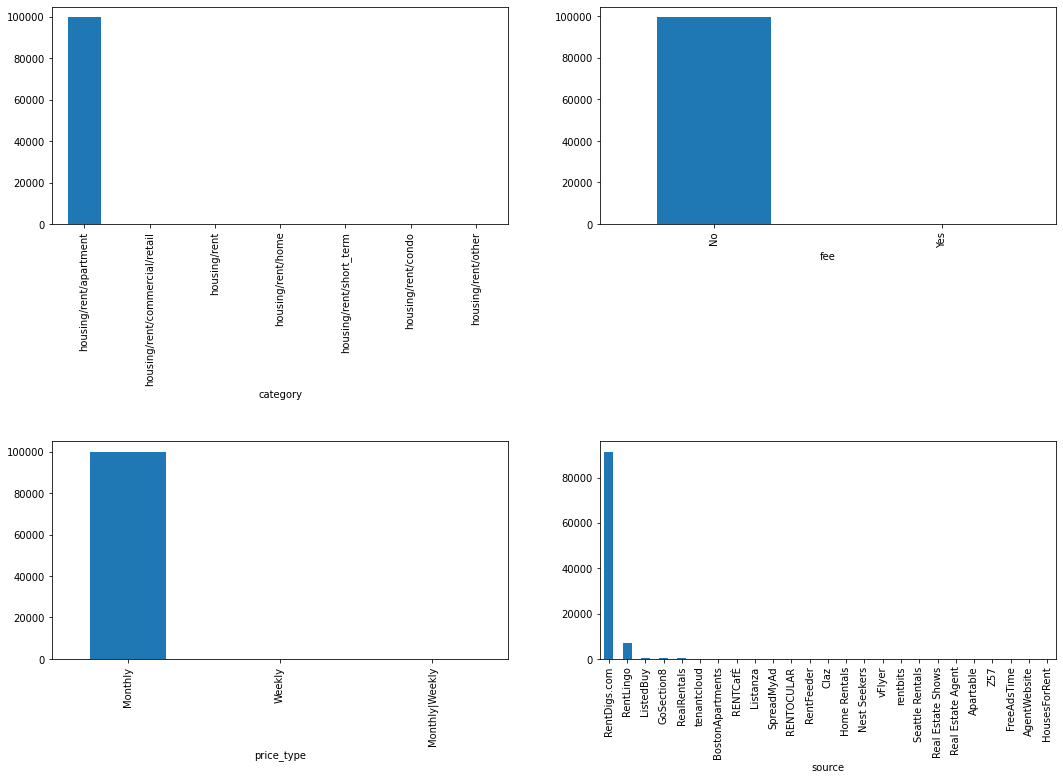

In [34]:
# Display 2x2 plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Create a histogram for categories
df['category'].value_counts().plot(kind='bar', ax=axes[0][0])
# Create a histogram for fee
df['fee'].value_counts().plot(kind='bar', ax=axes[0][1])
# Create a histogram for price_type
df['price_type'].value_counts().plot(kind='bar', ax=axes[1][0])
# Create a histogram for source
df['source'].value_counts().plot(kind='bar', ax=axes[1][1])

# Increase vertical spacing
plt.subplots_adjust(hspace=1)
plt.show()

<b> Observations: </b>
- Most rows belong to one category 'housing/rent/apartment' and there are only a few rows that belong to other categories.
- Most rows belong to 'No' fee category and there are only a few rows that belong 'Yes'
- Most rows belong to 'Monthly' price type category and there are only 3 that belong to 'Weekly' and 1 to 'Monthly|Weekly'
- Most rows belong to 'RentDIgs.com' source category and there are only a few rows that belong to other sources.
- The data is highly right skewed in all three of these columns, this indicates an extreme class imbalance.
- Since there is almost no variance, it will not add any predictive value and can be dropped.

In [35]:
# Drop category column
df = df.drop(columns=['category'])
# Drop fee column
df = df.drop(columns=['fee'])
# Drop price type column
df = df.drop(columns=['price_type'])
# Drop source column
df = df.drop(columns=['source'])

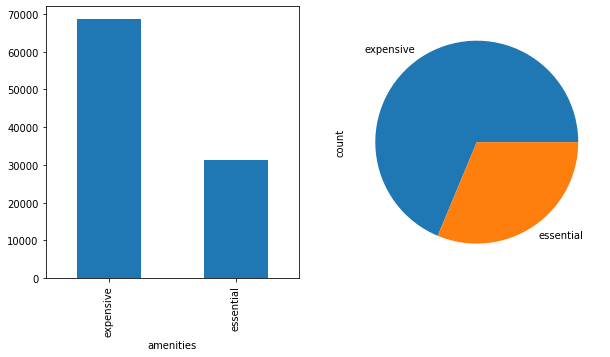

In [36]:
# Display 1x2 plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df['amenities'].value_counts().plot(kind='bar', ax=axes[0])
df['amenities'].value_counts().plot(kind='pie', ax=axes[1]);

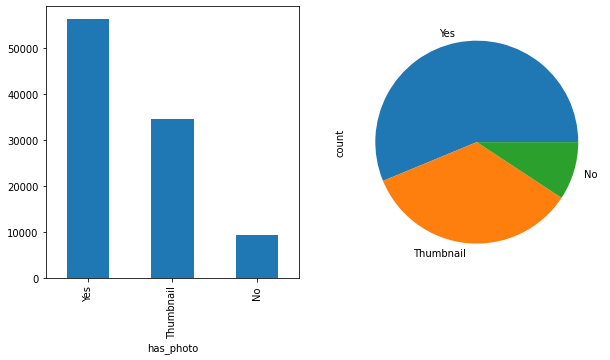

In [37]:
# Display 1x2 plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df['has_photo'].value_counts().plot(kind='bar', ax=axes[0])
df['has_photo'].value_counts().plot(kind='pie', ax=axes[1]);

<b> Observations: <b/>
- Expensive amenities appear more common than essential ones. There are roughly twice as many expensive amenities compared to essential ones.
- The majority of listings have photos. The number of listings with thumbnails is noticeably smaller, roughly one third less than those with full photos. Listings with no photos are the least common, about half as many as those with thumbnails.

In [38]:
# Drop price display column as it represents the same data as price just in a different non numeric format
df = df.drop(columns=['price_display'])

In [39]:
df.head()

,amenities,bathrooms,bedrooms,has_photo,price,square_feet,latitude,longitude,time_formatted,year,month,pet_Cats,pet_Dogs,pet_None
0,essential,1.0,1.0,Thumbnail,2195.0,542.0,33.8520,-118.3759,2019-12-26 11:39:15,2019,12,1,0,0
1,essential,1.5,3.0,Thumbnail,1250.0,1500.0,37.0867,-76.4941,2019-12-26 11:39:00,2019,12,1,1,0
2,essential,2.0,3.0,Thumbnail,1395.0,1650.0,35.8230,-78.6438,2019-12-26 11:38:52,2019,12,0,0,1
3,essential,1.0,2.0,Thumbnail,1600.0,820.0,38.3622,-121.9712,2019-12-26 11:38:50,2019,12,1,1,0
4,essential,1.0,1.0,Thumbnail,975.0,624.0,35.1038,-106.6110,2019-12-26 11:38:28,2019,12,1,1,0


In [40]:
# Types of numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
numerical_cols

Index(['bathrooms', 'bedrooms', 'price', 'square_feet', 'latitude',
       'longitude', 'year', 'month', 'pet_Cats', 'pet_Dogs', 'pet_None'],
      dtype='object')

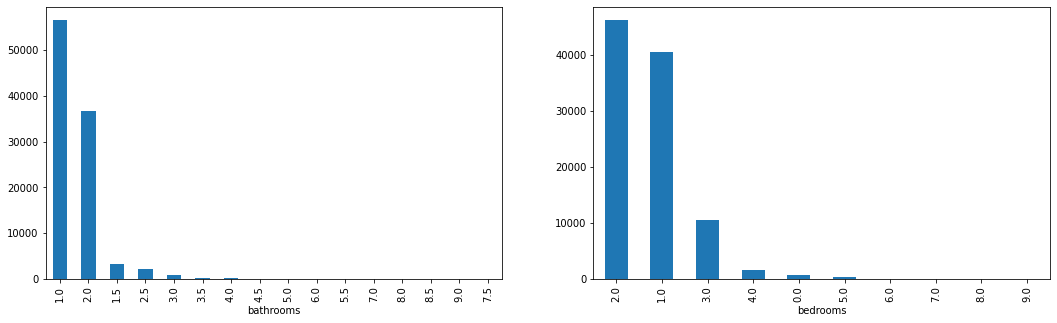

In [41]:
# Inspect bathrooms and bedrooms counts distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df['bathrooms'].value_counts().plot(kind='bar', ax=axes[0])
df['bedrooms'].value_counts().plot(kind='bar', ax=axes[1]);

<b> Observations: </b>
- Most listings have 2 or fewer bedrooms, we can notice that the distribution is right-skewed which indicates very few large houses.
- Only a handful of listings have more than 4 bathrooms, we can hardly see it in the graph, indicating luxury homes are rare.
- There’s a sharp dip after 3 bedrooms wich could mean that the dataset mostly covers apartments, not houses.

<Axes: xlabel='year'>

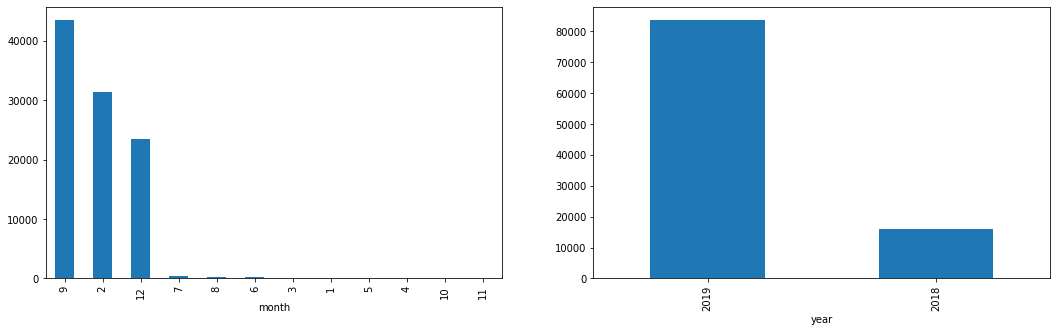

In [42]:
# Inspect months and years of listings distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df['month'].value_counts().plot(kind='bar', ax=axes[0])
df['year'].value_counts().plot(kind='bar', ax=axes[1])

<b> Observations: </b>
- The majority of listings occur in 2019, with a slightly lower number in 2018. We only have data for these two years.
- The highest listing activity occurs in September, February, and December months. September could be popular as this is the time when people are back from summer holidays and searching for places to live if relocating. February is in WInter just before SPring begins, the demand might be high as that is usually when the weather starts to warm up and people might be looking for holiday homes or a fresh start. December is the third highest listing count, this could be due to holidays discounts on properties during Christmas time.
- The lowest listings months are Spring and late fall. A few more listings occur in SUmmer but barely any compared to the top 3 months.

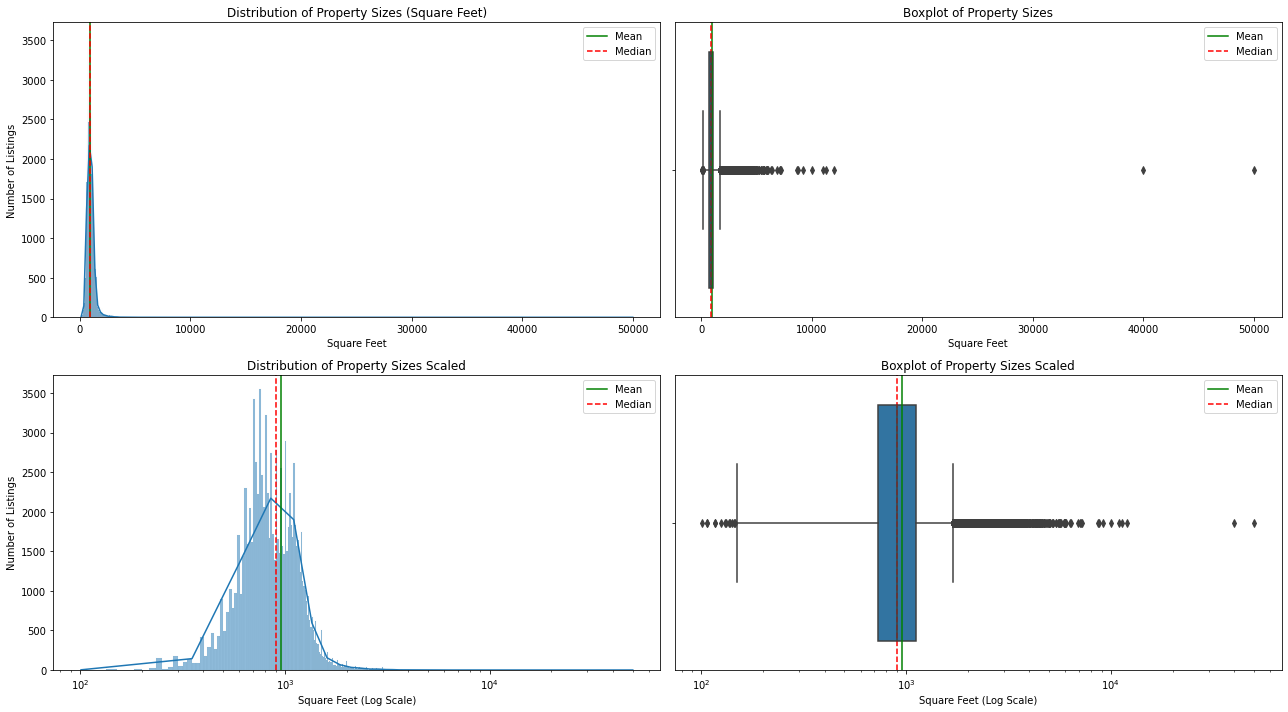

In [43]:
# Set plot size
plt.figure(figsize=(18, 10))

# Make the first subplot (two rows, two columns, first plot)
plt.subplot(2, 2, 1)

# Histogram: Distribution of square footage
sns.histplot(x=df['square_feet'], kde=True)
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")
plt.title("Distribution of Property Sizes (Square Feet)")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the second subplot
plt.subplot(2, 2, 2)

# Boxplot: Square footage distribution
sns.boxplot(x=df['square_feet'])
plt.xlabel("Square Feet")
plt.title("Boxplot of Property Sizes")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the third subplot
plt.subplot(2, 2, 3)

# Histogram (log scale): Square footage distribution scaled
sns.histplot(x=df['square_feet'], kde=True)
plt.xscale('log')
plt.xlabel("Square Feet (Log Scale)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Property Sizes Scaled")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the fourth subplot
plt.subplot(2, 2, 4)

# Boxplot (log scale): Square footage scaled
sns.boxplot(x=df['square_feet'])
plt.xscale('log')
plt.xlabel("Square Feet (Log Scale)")
plt.title("Boxplot of Property Sizes Scaled")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Adjust layout and show
plt.tight_layout()
plt.show()


<b> Observations: </b>
- The linear plot of square footage indicates a right-skewed distribution. Most properties have relatively small to medium-sized areas, concentrated on the left side of the plot.
- Applying logarithmic scaling to the square footage axis helps reveal the shape of the majority of the data without being dominated by extreme values. After log-scaling, the distribution appears more symmetric, making peaks and common property sizes easier to identify.
- On the linear scale, a few extreme outliers are noticeable, such as properties with very large areas of 40,000 or 50,000 square feet. These could represent luxury estates, commercial properties, or data entry errors.
- To determine whether these outliers should be treated separately, the IQR (Interquartile Range) method can be applied. This ensures that typical property sizes are not skewed by a few extreme values while still preserving valid large properties for analysis.

In [44]:
# Formula to calculate IQR: q3 - q1
q1 = df['square_feet'].quantile(0.25)
q3 = df['square_feet'].quantile(0.75)
iqr = q3 - q1
print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)

# Formula to calculate upper whisker: q3 + 1.5 * IQR
upper_whisker_sqrft = q3 + 1.5 * iqr
print("Upper whisker:", upper_whisker_sqrft)

# Formula to calculate lower whisker: q3 - 1.5 * IQR
lower_whisker_sqrft = q3 - 1.5 * iqr
print("Lower whisker:", lower_whisker_sqrft)

Q1: 729.0 | Q3: 1115.0 | IQR: 386.0
Upper whisker: 1694.0
Lower whisker: 536.0


In [45]:
# Show number of outliers
upper_outliers = df[df['square_feet'] > upper_whisker_sqrft].index
lower_outliers = df[df['square_feet'] < lower_whisker_sqrft].index
all_outliers = len(upper_outliers) + len(lower_outliers)

print("Upper Outliers: ", len(upper_outliers))
print("Lower Outliers: ", len(lower_outliers))
print("Outliers: ", all_outliers)

Upper Outliers:  2844
Lower Outliers:  5149
Outliers:  7993


In [46]:
# Top 3 smallest area
print(df.nsmallest(3, 'square_feet'))

      amenities  bathrooms  bedrooms  has_photo   price  square_feet  \
4942  essential        1.0       0.0  Thumbnail   790.0        101.0   
6292  essential        1.0       1.0  Thumbnail   425.0        106.0   
4998  essential        1.0       0.0  Thumbnail  1390.0        107.0   

      latitude  longitude      time_formatted  year  month  pet_Cats  \
4942   38.9057   -76.9861 2019-12-26 11:23:35  2019     12         0   
6292   37.9680   -87.6621 2019-12-22 12:17:43  2019     12         0   
4998   38.8910   -77.0816 2019-12-26 11:23:30  2019     12         0   

      pet_Dogs  pet_None  
4942         0         1  
6292         0         1  
4998         0         1  


In [47]:
# Top 3 largest area
print(df.nsmallest(3, 'square_feet'))

      amenities  bathrooms  bedrooms  has_photo   price  square_feet  \
4942  essential        1.0       0.0  Thumbnail   790.0        101.0   
6292  essential        1.0       1.0  Thumbnail   425.0        106.0   
4998  essential        1.0       0.0  Thumbnail  1390.0        107.0   

      latitude  longitude      time_formatted  year  month  pet_Cats  \
4942   38.9057   -76.9861 2019-12-26 11:23:35  2019     12         0   
6292   37.9680   -87.6621 2019-12-22 12:17:43  2019     12         0   
4998   38.8910   -77.0816 2019-12-26 11:23:30  2019     12         0   

      pet_Dogs  pet_None  
4942         0         1  
6292         0         1  
4998         0         1  


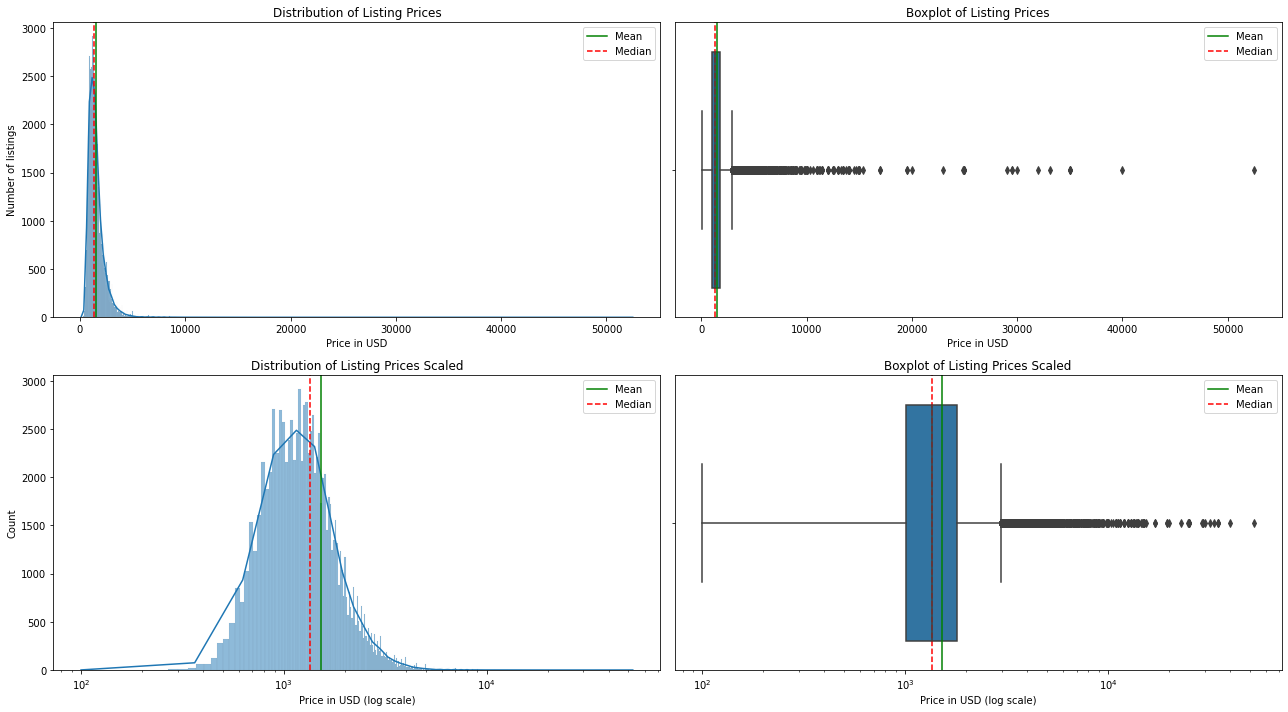

In [48]:
# Set plot size
plt.figure(figsize=(18, 10))

# Make the first subplot (two rows, two columns, first plot)
plt.subplot(2, 2, 1)

# Histogram: Price amount per listing
sns.histplot(x = df['price'], kde=True)
plt.xlabel("Price in USD")
plt.ylabel("Number of listings")
plt.title("Distribution of Listing Prices")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Second subplot
plt.subplot(2, 2, 2)

# Boxplot: Price amount per listing
sns.boxplot(x = df['price'])
plt.xlabel("Price in USD")
plt.title("Boxplot of Listing Prices")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the third subplot
plt.subplot(2, 2, 3)

# Histogram: Price amount per listing in log scale
sns.histplot(x=df['price'], kde=True)
plt.xscale('log')
plt.xlabel("Price in USD (log scale)")
plt.title("Distribution of Listing Prices Scaled")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the fourth subplot
plt.subplot(2, 2, 4)

# Boxplot: Price amount per listing in log scale
sns.boxplot(x=df['price'])
plt.xscale('log')
plt.xlabel("Price in USD (log scale)")
plt.title("Boxplot of Listing Prices Scaled")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Show the four plots
plt.tight_layout()
plt.show()

<b> Observations: </b>
- The linear plot indicates exponential distribution. Most of the price data is on the left side of the plot.
- We applied logarithmic scaling to the price axis to inspect elemnets when outliers are not hiding the shape of the majority data. Since the data is more symetric, peaks are easier to see now. It looks more like a normal distribution.
- With linear distribution, we notice a few outliers such as one at around 55000 USD or 40000 USD. The extreme values on the higher end indicate that there are a few properties with significantly higher prices. These outliers could represent high-end properties or errors in data entry. To determine whether to treat them as outliers, we can use the IQR (Interquartile Range) method to check if they lie beyond the acceptable range.

In [49]:
# Formula to calculate IQR: q3 - q1
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
print("Q1:", q1, "| Q3:", q3, "| IQR:", iqr)

# Formula to calculate upper whisker: q3 + 1.5 * IQR
upper_whisker = q3 + 1.5 * iqr
print("Upper whisker:", upper_whisker)

# Formula to calculate lower whisker: q3 - 1.5 * IQR
lower_whisker = q3 - 1.5 * iqr
print("Lower whisker:", lower_whisker)

Q1: 1014.0 | Q3: 1795.0 | IQR: 781.0
Upper whisker: 2966.5
Lower whisker: 623.5


In [50]:
# Show number of outliers
upper_outliers = df[df['price'] > upper_whisker].index
lower_outliers = df[df['price'] < lower_whisker].index
all_outliers = len(upper_outliers) + len(lower_outliers)

print("Upper Outliers: ", len(upper_outliers))
print("Lower Outliers: ", len(lower_outliers))
print("Outliers: ", all_outliers)

Upper Outliers:  4709
Lower Outliers:  2555
Outliers:  7264


In [51]:
# Top 3 lowest prices
print(df.nsmallest(3, 'price'))

       amenities  bathrooms  bedrooms  has_photo  price  square_feet  \
52249  expensive        1.0       2.0  Thumbnail  100.0        800.0   
6286   essential        1.0       1.0  Thumbnail  200.0        250.0   
53433  essential        1.0       0.0        Yes  200.0        800.0   

       latitude  longitude      time_formatted  year  month  pet_Cats  \
52249   41.7856   -72.6730 2019-10-25 19:10:09  2019     10         0   
6286    39.3903   -77.1487 2019-12-22 11:44:59  2019     12         0   
53433   35.2812   -93.1390 2019-02-22 18:08:15  2019      2         0   

       pet_Dogs  pet_None  
52249         0         1  
6286          0         1  
53433         0         1  


In [52]:
# Top 3 highest prices
print(df.nlargest(3, 'price'))

       amenities  bathrooms  bedrooms  has_photo    price  square_feet  \
6863   expensive        1.0       0.0  Thumbnail  52500.0       1418.0   
41358  expensive        8.0       6.0        Yes  40000.0       7145.0   
17206  essential        4.0       4.0  Thumbnail  35000.0       2269.0   

       latitude  longitude      time_formatted  year  month  pet_Cats  \
6863    34.8870  -117.0350 2019-12-24 11:08:32  2019     12         0   
41358   34.0584  -118.4135 2019-09-17 22:27:00  2019      9         0   
17206   34.0939  -118.3801 2019-09-17 22:45:38  2019      9         0   

       pet_Dogs  pet_None  
6863          0         1  
41358         0         1  
17206         0         1  


We will come back to outlier treatment later on.

## Bivariate analysis

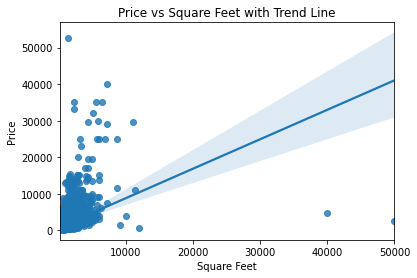

In [53]:
# Price vs sqr footage
sns.regplot(data=df, x='square_feet', y='price')
plt.title('Price vs Square Feet with Trend Line')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.show()

<b> Observations: </b>
- Most homes are of smaller area and lower price, meaning that this dataset consists of mostly mid-range houses and less of expensive, luxury homes.
- As the square footage increases, the price tends to increase as well based on this chart and the regression line indicates this as well.
- Scatter plots are still widely ranging as other factors also have a role to play, such as number of bedrooms and bathrooms.

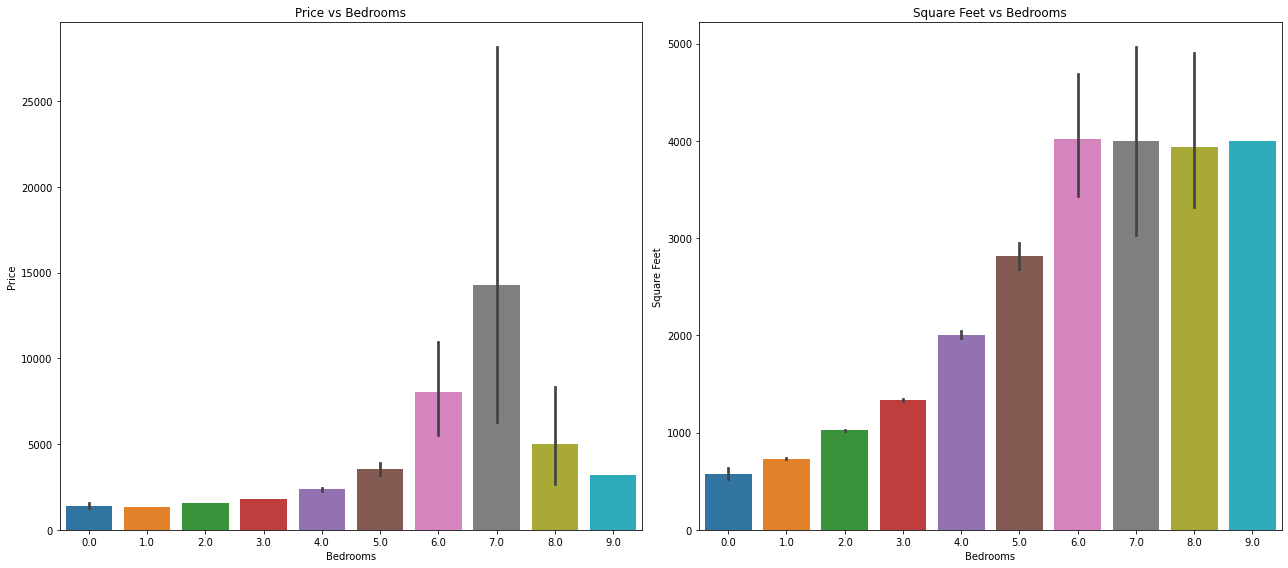

In [54]:
# Make subplots of size 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18,8))

# Price vs Bedrooms
sns.barplot(data=df, x='bedrooms', y='price', ax=axes[0])
axes[0].set_title('Price vs Bedrooms')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Price')

# Square Feet vs Bedrooms
sns.barplot(data=df, x='bedrooms', y='square_feet', ax=axes[1])
axes[1].set_title('Square Feet vs Bedrooms')
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

<b> Observations: </b>
- Price tends to be highest for properties with 6–8 bedrooms. Properties with fewer bedrooms (1–4) generally have lower prices.
- Beyond 7–8 bedrooms, the price does not continue to increase and may even decrease slightly as bedroom count rises further.
- The area of the property generally increases as the number of bedrooms increases.
- After reaching around 6 bedrooms, the area levels off and remains relatively consistent, even if the bedroom count increases further.

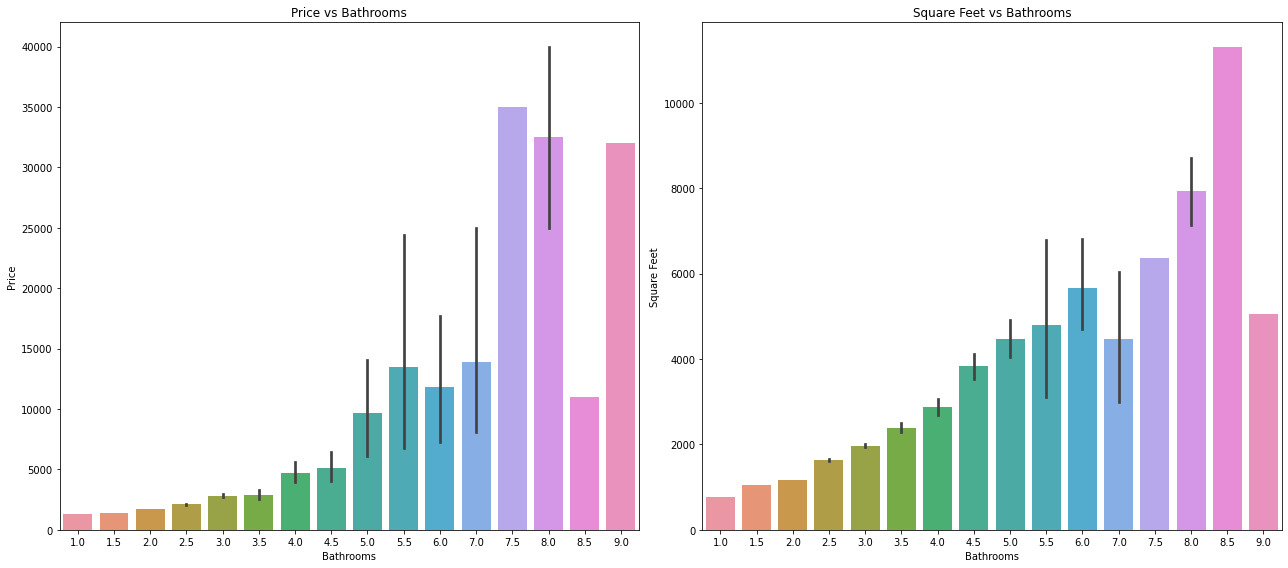

In [55]:
# Make subplots of size 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18,8))

# Price vs Bathrooms
sns.barplot(data=df, x='bathrooms', y='price', ax=axes[0])
axes[0].set_title('Price vs Bathrooms')
axes[0].set_xlabel('Bathrooms')
axes[0].set_ylabel('Price')

# Square Feet vs Bathrooms
sns.barplot(data=df, x='bathrooms', y='square_feet', ax=axes[1])
axes[1].set_title('Square Feet vs Bathrooms')
axes[1].set_xlabel('Bathrooms')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

<b> Observations: </b>
- Price generally increases as the number of bathrooms increases, though there are a few anomalies, such as when we have 8.5 bathrooms, where properties with more bathrooms do not have higher prices.
- Property area also increases with the number of bathrooms, showing a consistent upward trend with a dip when the number of bathrooms reaches 9.
- Unlike bedrooms, the upward trend for both price and area continues more or less steadily with more bathrooms, without flattening, indicating that additional bathrooms consistently add value and space to a property.

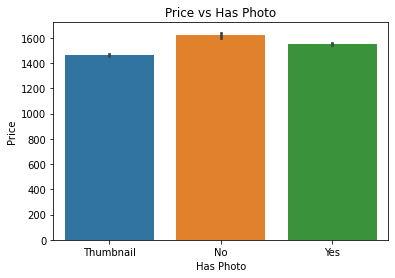

In [56]:
# Price vs Has Photo
sns.barplot(data=df, x='has_photo', y='price')
plt.title('Price vs Has Photo')
plt.xlabel('Has Photo')
plt.ylabel('Price')
plt.show()

<b> Observations: </b>
- Price is generally similar regardless of whether a listing has no photo, only a thumbnail, or full photos.
- Listings with no photos show a slightly higher average price compared to those with photos, though the difference is minimal.

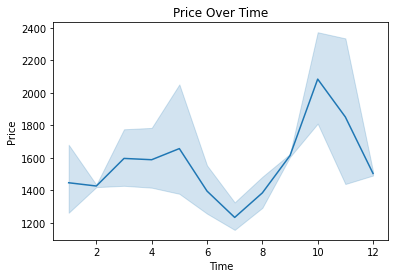

In [57]:
# Time Formatted vs Price
sns.lineplot(data=df.sort_values('month'), x='month', y='price')
plt.title('Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()

<b> Observations: </b>
- From the line plot, we can see that the highest sales months often coincide with periods when prices were relatively low.
- For example, in February, a top selling month, the price was lower, and then it gradually increased afterward before decreasing again.
- Similarly, in September and December, the price was low during high sales periods and then rose afterward.
- This suggests that sales tend to peak when prices are at their temporary lows.

## Multivariate analysis

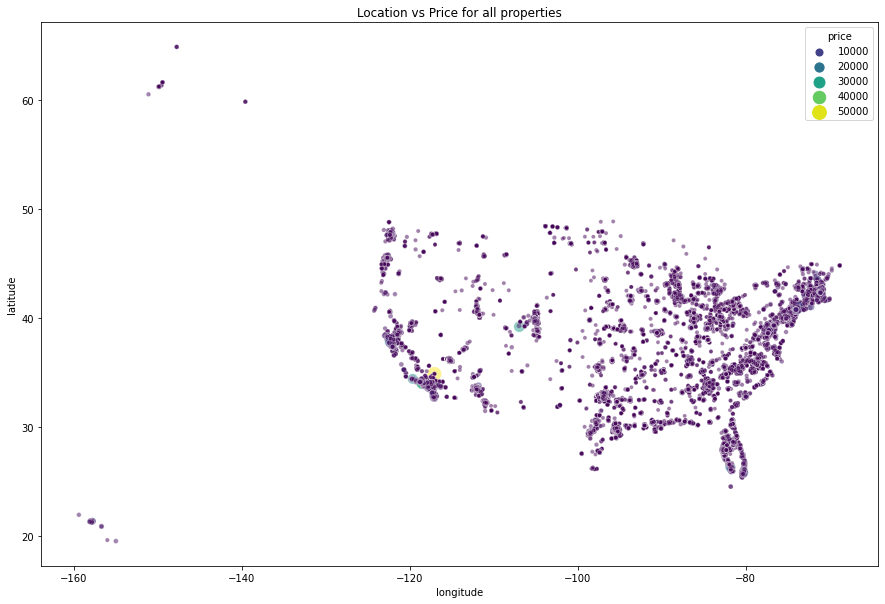

In [58]:
# Scatterplot for price distribution based on location
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='price', size='price', sizes=(15,200), alpha=0.5, palette='viridis')
plt.title("Location vs Price for all properties")
plt.show()

<b> Observations: </b>
- The scatterplot shape confirms that the data we are analysing is for listings in the US.
- By changing the alpha variable in the scatterplot, we notice that the majority of listings' data points are located in the eastern half of the United States.
- This includes dense markets like New York, Florida, Washington D.C., Boston, Atlanta areas. The east side of the USA has a lot of population centers and more properties per area.
- However the highest price properties are on the west side of the United States, in places such as LA, California. The higher property prices could be due to high popularity, tech hubs in the area, good weather, building regulations.

In [59]:
# To confirm the price differences based on west and east sides, we can check the average prices for these areas
west = df[df['longitude'] < -100]
east = df[df['longitude'] >= -100]

print("Average price (West):", west['price'].mean())
print("Average price (East):", east['price'].mean())

Average price (West): 1836.2490210242179
Average price (East): 1416.8447538733353


The price for the west side is indeed higher than east side.

### Feature correlation matrix

<Axes: >

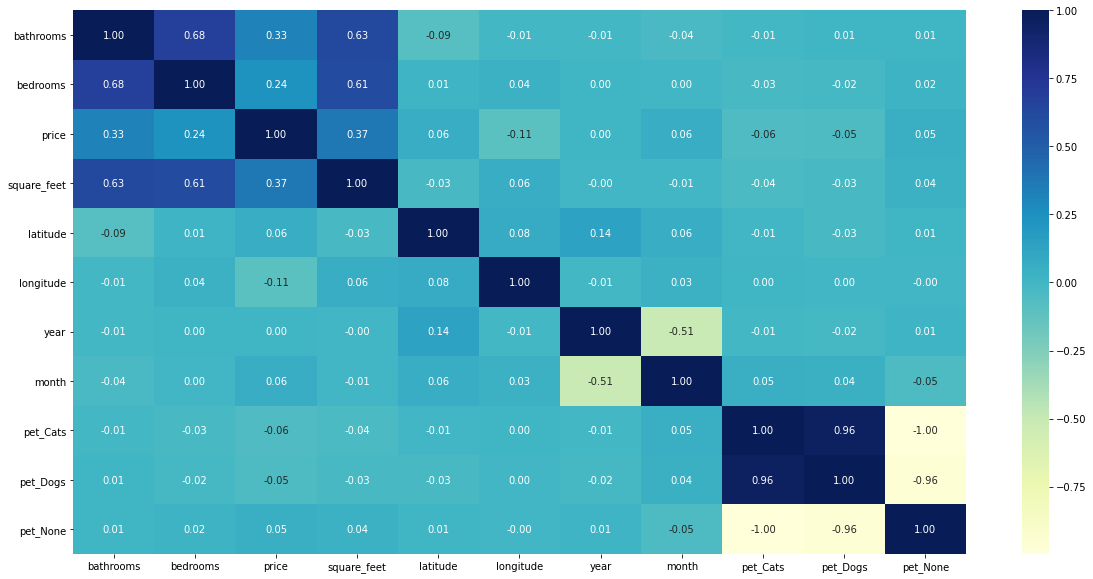

In [60]:
# Split numerical and categorical values
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Plotting the correlation between numerical variables
plt.figure(figsize = (20, 10))
sns.heatmap(df[num_cols].corr(), annot = True, fmt = '0.2f', cmap = 'YlGnBu')

<b> Observations: </b>
- The correlation matrix shows that price is most strongly correlated with area (square footage).
- There is also a moderate correlation between price and the number of bedrooms or bathrooms.
- However, the correlation scores for all three features are relatively low (below 0.4), suggesting that the predictive power of these individual features is limited and could potentially be improved through feature engineering or by incorporating additional variables.
- Other variables are not as strongly correlated to price.

## Feature engineering

In [61]:
# Combine bedrooms and bathrooms
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

Merging the counts of bedrooms and bathrooms into one variable provides a better representation of total living space. This feature can improve the model’s ability to capture how property size influences price.

In [62]:
# Create a feature that indicates how many rooms per bathroom
df['bed_bath_ratio'] = df['bedrooms'] / df['bathrooms']

- Homes with more bathrooms per bedroom are generally seen as more luxurious and convenient, often having higher prices.
- In contrast, a property with fewer bathrooms relative to bedrooms can signal crowding or lower-end design.
- By capturing this ratio, we help the model understand qualitative differences between similar-sized properties, this is something raw bedroom or bathroom counts can’t fully express.

In [63]:
# Creating log transformations to reduce skewness for later modelling
df['log_price'] = np.log1p(df['price'])
df['log_sqft'] = np.log1p(df['square_feet'])

<Axes: >

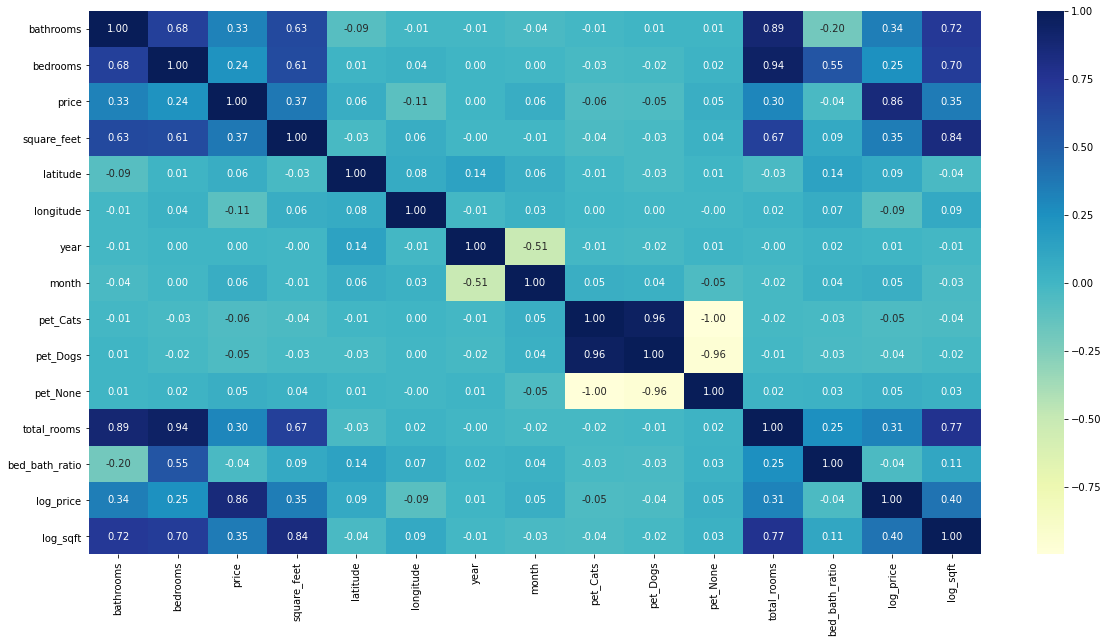

In [64]:
# Split numerical and categorical values
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Plotting the correlation between numerical variables
plt.figure(figsize = (20, 10))
sns.heatmap(df[num_cols].corr(), annot = True, fmt = '0.2f', cmap = 'YlGnBu')

We need to convert the categorical features into numerical ones.

### Encoding categories

In [65]:
# Check has_photo categories
df['has_photo'].unique()

array(['Thumbnail', 'No', 'Yes'], dtype=object)

In [66]:
# One-hot encode has photo with a prefix
df = df.join(df['has_photo'].str.get_dummies().add_prefix('photo_'))

# Drop the 'has_photo' column
df = df.drop(columns=['has_photo'])

Has photo column has been encoded using one-hot encoding, now let's repeat this for amenities.

In [67]:
# Check amenities categories
df['amenities'].unique()

array(['essential', 'expensive'], dtype=object)

In [68]:
# One-hot encode amenities with a prefix
df = df.join(df['amenities'].str.get_dummies().add_prefix('amenities_'))

# Drop the 'amenities' column
df = df.drop(columns=['amenities'])

Now amenities have been successfully one-hot encoded as well.

In [69]:
# Check current data and columns
df.head()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,time_formatted,year,month,pet_Cats,...,pet_None,total_rooms,bed_bath_ratio,log_price,log_sqft,photo_No,photo_Thumbnail,photo_Yes,amenities_essential,amenities_expensive
0,1.0,1.0,2195.0,542.0,33.8520,-118.3759,2019-12-26 11:39:15,2019,12,1,...,0,2.0,1.0,7.694393,6.297109,0,1,0,1,0
1,1.5,3.0,1250.0,1500.0,37.0867,-76.4941,2019-12-26 11:39:00,2019,12,1,...,0,4.5,2.0,7.131699,7.313887,0,1,0,1,0
2,2.0,3.0,1395.0,1650.0,35.8230,-78.6438,2019-12-26 11:38:52,2019,12,0,...,1,5.0,1.5,7.241366,7.409136,0,1,0,1,0
3,1.0,2.0,1600.0,820.0,38.3622,-121.9712,2019-12-26 11:38:50,2019,12,1,...,0,3.0,2.0,7.378384,6.710523,0,1,0,1,0
4,1.0,1.0,975.0,624.0,35.1038,-106.6110,2019-12-26 11:38:28,2019,12,1,...,0,2.0,1.0,6.883463,6.437752,0,1,0,1,0


### Preprocessing Continuous Data and treating outliers

In [70]:
# We assign outliers to the closest whisker value using clamp method
df['square_feet'] = df['square_feet'].clip(lower=lower_whisker_sqrft, upper=upper_whisker_sqrft)

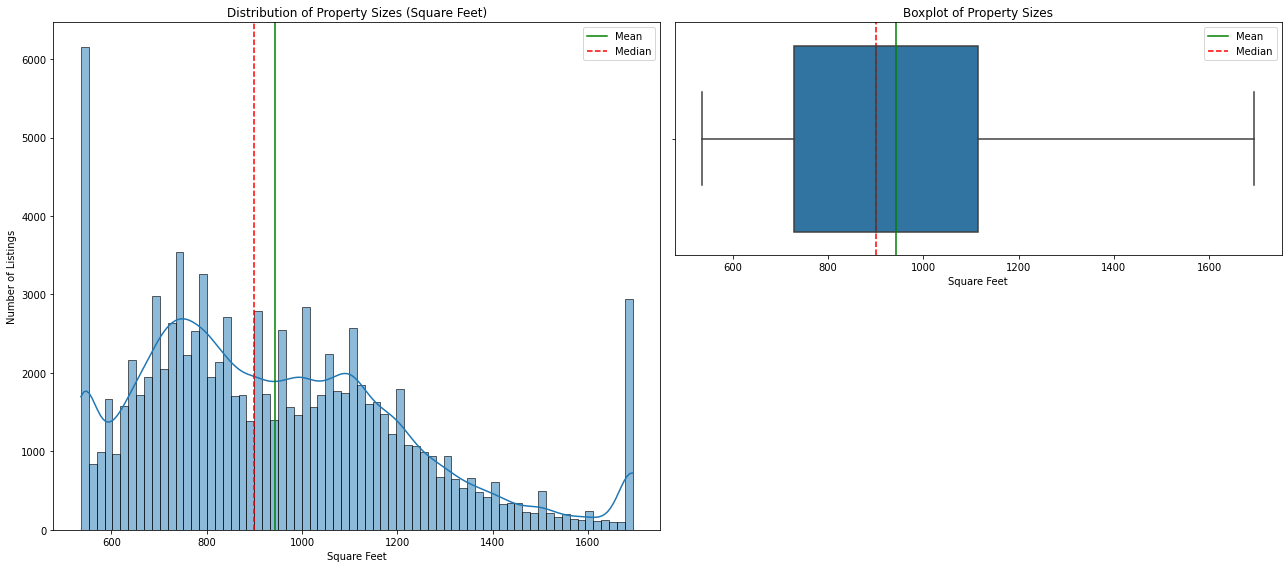

In [71]:
# Set plot size
plt.figure(figsize=(18, 8))

# Make the first subplot
plt.subplot(1, 2, 1)

# Histogram: Distribution of square footage
sns.histplot(x=df['square_feet'], kde=True)
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")
plt.title("Distribution of Property Sizes (Square Feet)")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Make the second subplot
plt.subplot(2, 2, 2)

# Boxplot: Square footage distribution
sns.boxplot(x=df['square_feet'])
plt.xlabel("Square Feet")
plt.title("Boxplot of Property Sizes")
plt.axvline(df['square_feet'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['square_feet'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Show the new plots
plt.tight_layout()
plt.show()

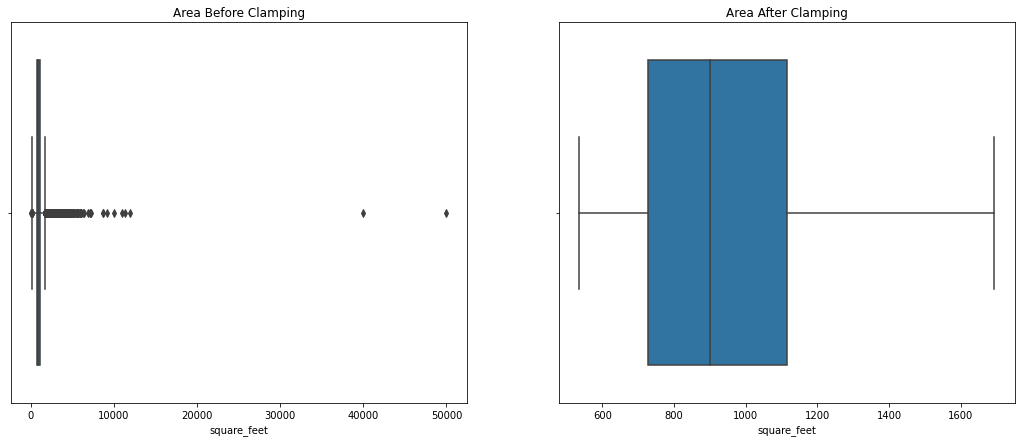

In [72]:
# Let's compare the difference clamping made to the distribution of data side by side
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Original data
sns.boxplot(x=data['square_feet'], ax=ax[0])
ax[0].set_title('Area Before Clamping')

# New cleaned data
sns.boxplot(x=df['square_feet'], ax=ax[1])
ax[1].set_title('Area After Clamping')

plt.show()

<b> Observations: </b>
- The data distribution balance has improved after using clamp transformation method on outliers.
- Outliers were capped to reduce skewness, improving model stability and ensuring that the feature better represents typical property sizes.
- Extreme outliers such as properties with unrealistically large or small square footage have been capped to the nearest whisker values, reducing the overall spread.

In [73]:
# We assign outliers to the closest whisker value using clamp method
df['price'] = df['price'].clip(lower=lower_whisker, upper=upper_whisker)

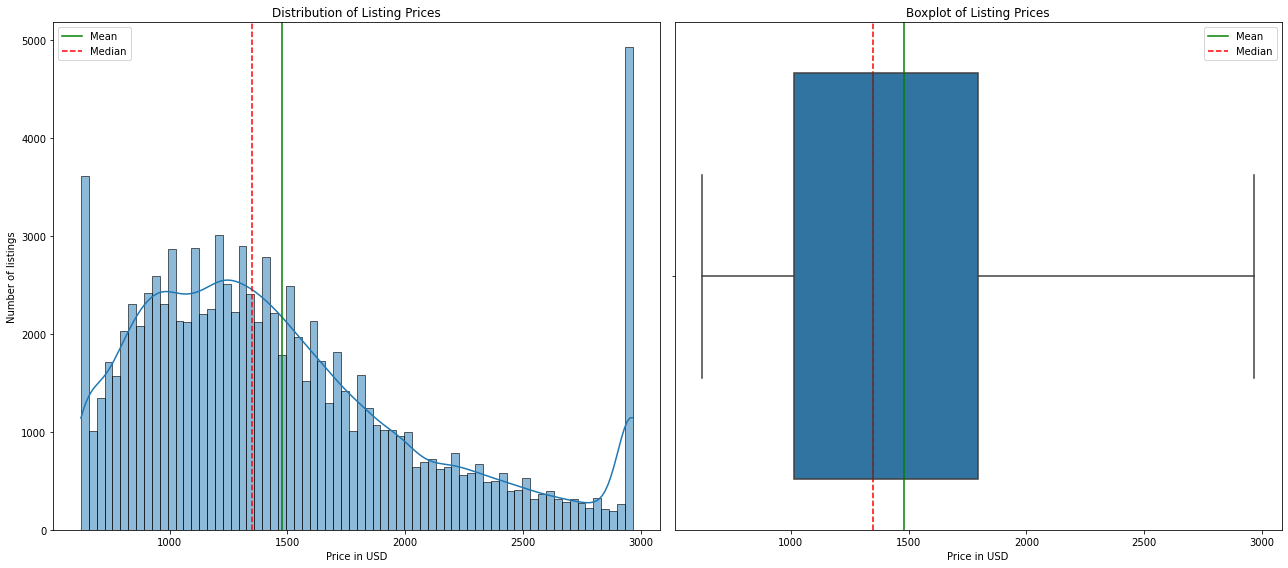

In [74]:
# Set plot size
plt.figure(figsize=(18, 8))

# Make the first subplot
plt.subplot(1, 2, 1)

# Histogram: Price amount per listing
sns.histplot(x = df['price'], kde=True)
plt.xlabel("Price in USD")
plt.ylabel("Number of listings")
plt.title("Distribution of Listing Prices")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Second subplot
plt.subplot(1, 2, 2)

# Boxplot: Price amount per listing
sns.boxplot(x = df['price'])
plt.xlabel("Price in USD")
plt.title("Boxplot of Listing Prices")
plt.axvline(df['price'].mean(), color='green', linestyle='-', label='Mean')
plt.axvline(df['price'].median(), color='red', linestyle='--', label='Median')
plt.legend()

# Show the new plots
plt.tight_layout()
plt.show()

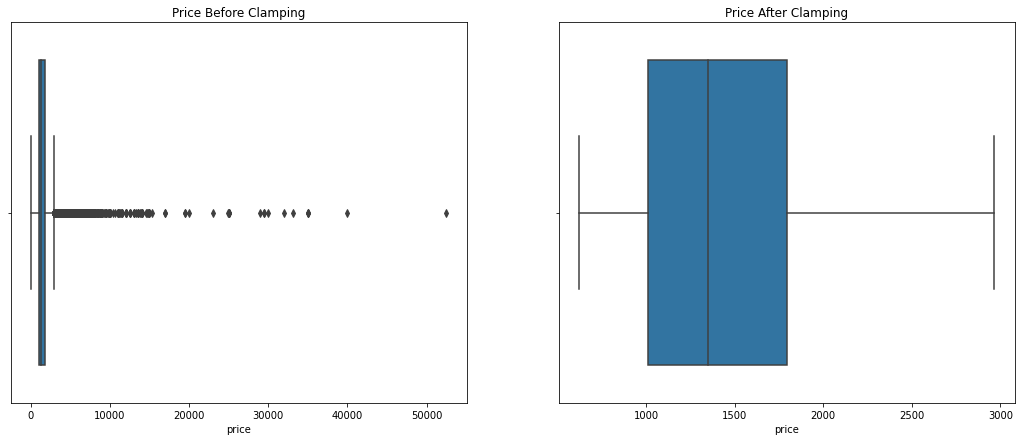

In [75]:
# Let's compare the difference clamping made to the distribution of data side by side
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Original data
sns.boxplot(x=data['price'], ax=ax[0])
ax[0].set_title('Price Before Clamping')

# New cleaned data
sns.boxplot(x=df['price'], ax=ax[1])
ax[1].set_title('Price After Clamping')

plt.show()

<b> Observations: </b>
- After applying the clamp transformation to the price variable, the overall distribution became more balanced and less right-skewed.
- Extremely high priced listings that previously distorted the distribution have been capped to the upper whisker value, resulting in a tighter, more consistent range of prices.
- This adjustment reduces the influence of extreme luxury properties that could bias the model’s learning process.

## Model building

<b> Data preparation </b>

In [76]:
# Let's have a look at all columns that we have and choose which we will use for modeling
df.columns.tolist()

['bathrooms',
 'bedrooms',
 'price',
 'square_feet',
 'latitude',
 'longitude',
 'time_formatted',
 'year',
 'month',
 'pet_Cats',
 'pet_Dogs',
 'pet_None',
 'total_rooms',
 'bed_bath_ratio',
 'log_price',
 'log_sqft',
 'photo_No',
 'photo_Thumbnail',
 'photo_Yes',
 'amenities_essential',
 'amenities_expensive']

In [77]:
# Seperate independent variables, drop any useless variables
X = df[['bathrooms',
        'bedrooms',
        'square_feet',
        'year',
        'month',
        'pet_Cats',
        'pet_Dogs',
        'pet_None',
        'total_rooms',
        'bed_bath_ratio',
        'log_sqft',
        'photo_No',
        'photo_Thumbnail',
        'photo_Yes',
        'amenities_essential',
        'amenities_expensive']]

# Seperate target variable
y = df['price']

In [78]:
# Check the shape of data
X.shape

(99883, 16)

In [79]:
# Let's check data quality report after processing the data
data_quality_numeric(X)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
bathrooms,99883.0,0.0,16,1.000000,1.000000,1.445056,1.000000,2.000000,9.000000,0.546848
bedrooms,99883.0,0.0,10,0.000000,1.000000,1.728202,2.000000,2.000000,9.000000,0.748581
square_feet,99883.0,0.0,1158,536.000000,729.000000,943.286035,900.000000,1115.000000,1694.000000,278.700455
year,99883.0,0.0,2,2018.000000,2019.000000,2018.839052,2019.000000,2019.000000,2019.000000,0.367485
month,99883.0,0.0,12,1.000000,2.000000,7.461870,9.000000,9.000000,12.000000,3.915956
pet_Cats,99883.0,0.0,2,0.000000,0.000000,0.391288,0.000000,1.000000,1.000000,0.488041
pet_Dogs,99883.0,0.0,2,0.000000,0.000000,0.374098,0.000000,1.000000,1.000000,0.483891
pet_None,99883.0,0.0,2,0.000000,0.000000,0.607451,1.000000,1.000000,1.000000,0.488320
total_rooms,99883.0,0.0,26,1.000000,2.000000,3.173258,3.000000,4.000000,15.000000,1.189718
bed_bath_ratio,99883.0,0.0,36,0.000000,1.000000,1.231250,1.000000,1.333333,6.000000,0.468904


<b> Observations: </b>
- The dataset shows strong consistency with no missing values across ~99K records. This is because proper missing value treatment has been applied.
- Most features have reasonable distributions, though square_feet and bedrooms exhibit mild right-skewness due to larger luxury properties. This can be fixed using scaling before modelling with knn.
- Binary variables are properly encoded and balanced, and engineered features such as log_sqft and bed_bath_ratio appear valid.
- The general data quality is good and suitable for modeling after standard scaling.
- We will not check data quality report for categorical features at this time as we have eliminated them and transformed to numerical.

<b> Partition the data into train and test set </b>

In [80]:
# Split into training and testing data
# Using 15% of data for testing as I will be splitting data into 70/15/15 for train/val/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42, shuffle = True)

In [81]:
# Make sure data remains the correct size
print(f"Train {X_train.shape}, Test: {X_test.shape}")

Train (84900, 16), Test: (14983, 16)


In [82]:
# Now split the remaining 85% into train and validation
validation_fraction = 0.15/0.85
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_fraction, random_state=42, shuffle=True)

# Check the sizes
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (69917, 16), Validation: (14983, 16), Test: (14983, 16)


### Scaling Data

Knn algorithm is a distance based algorithm, this means it is sensitive to the scale of the variables. Therefore, we scale our data before applying the algorithm.

In [83]:
# Applying standard scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transforming validation and testing using scaler from train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Converting scaled data to a dataframe
df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_scaled.head()

,bathrooms,bedrooms,square_feet,year,month,pet_Cats,pet_Dogs,pet_None,total_rooms,bed_bath_ratio,log_sqft,photo_No,photo_Thumbnail,photo_Yes,amenities_essential,amenities_expensive
0,-0.811223,-0.971488,-1.016574,0.439017,0.392452,1.254470,1.299540,-1.251153,-0.984408,-0.494432,-0.931403,-0.320042,-0.727284,0.884362,-0.67687,0.67687
1,-0.811223,-0.971488,-1.048831,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.972301,-0.320042,-0.727284,0.884362,-0.67687,0.67687
2,-0.811223,-0.971488,-0.210158,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.057608,-0.320042,-0.727284,0.884362,-0.67687,0.67687
3,-0.811223,-0.971488,-0.564981,0.439017,-1.393780,1.254470,1.299540,-1.251153,-0.984408,-0.494432,-0.410973,-0.320042,-0.727284,0.884362,-0.67687,0.67687
4,-0.811223,-0.971488,-0.511220,0.439017,0.392452,-0.797149,-0.769503,0.799262,-0.984408,-0.494432,-0.354664,-0.320042,-0.727284,0.884362,-0.67687,0.67687


In [84]:
# Let's check data quality report after scaling the data
data_quality_numeric(df_scaled)

,Count,% Miss,Card.,Min,Q1,Mean,Median,Q3,Max,Std. Dev.
bathrooms,69917.0,0.0,15,-0.811223,-0.811223,1.097567e-16,-0.811223,1.016924,12.899878,1.000007
bedrooms,69917.0,0.0,10,-2.306306,-0.971488,1.018299e-16,0.363330,0.363330,9.707056,1.000007
square_feet,69917.0,0.0,1157,-1.457416,-0.769273,1.953263e-16,-0.152812,0.614180,2.692943,1.000007
year,69917.0,0.0,2,-2.277815,0.439017,-1.395570e-13,0.439017,0.439017,0.439017,1.000007
month,69917.0,0.0,12,-1.648955,-1.393780,-1.022364e-16,0.392452,0.392452,1.157980,1.000007
pet_Cats,69917.0,0.0,2,-0.797149,-0.797149,2.703268e-17,-0.797149,1.254470,1.254470,1.000007
pet_Dogs,69917.0,0.0,2,-0.769503,-0.769503,1.117893e-18,-0.769503,1.299540,1.299540,1.000007
pet_None,69917.0,0.0,2,-1.251153,-1.251153,-3.191075e-17,0.799262,0.799262,0.799262,1.000007
total_rooms,69917.0,0.0,25,-1.824672,-0.984408,5.813042e-17,-0.144144,0.696120,9.518891,1.000007
bed_bath_ratio,69917.0,0.0,35,-2.623214,-0.494432,-3.587419e-16,-0.494432,0.417903,10.149478,1.000007


- Before scaling, square_feet had large numeric variation, ranging from ~530 to ~1700 sqrft.
- After scaling, mean is near 0 and std. dev is about 1, ensuring that square footage no longer dominates smaller-valued features such as bedrooms and bathrooms.
- This is crucial for Knn, where distances would otherwise be driven almost entirely by square_feet. Scaling ensures all features contribute proportionally to similarity calculations.

In [85]:
# Creating metrics function for evaluation
def metrics(actual, predicted, dataset_name):
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    
    return {'Dataset': dataset_name, 'MAE': mae, 'MAPE (%)': mape, 'RMSE': rmse, 'R²': r2}

In [86]:
# We will need to evaluate models on train, val, test sets
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_tesvt, model_name):
    results = []
    
    # Training set
    y_train_pred = model.predict(X_train)
    results.append(metrics(y_train, y_train_pred, 'Train'))
    
    # Validation set
    y_val_pred = model.predict(X_val)
    results.append(metrics(y_val, y_val_pred, 'Validation'))
    
    # Test set
    y_test_pred = model.predict(X_test)
    results.append(metrics(y_test, y_test_pred, 'Test'))
    
    # Create DataFrame
    df_results = pd.DataFrame(results)
    df_results.insert(0, 'Model', model_name)
    
    return df_results

In [87]:
# Store all results for different models here
all_results = []

In [88]:
# KNN - K-Nearest Neighbours
print("Training KNN...")
# Default values for knn parameters are n_neighbors=5 and weights='uniform'
knn_selection = [{'n_neighbors': 3, 'weights': 'uniform'},
                 {'n_neighbors': 5, 'weights': 'uniform'},
                 {'n_neighbors': 10, 'weights': 'uniform'}]

for params in knn_selection:
    # Model with hyperparameters
    knn = KNeighborsRegressor(**params)
    # Train on training set
    knn.fit(X_train_scaled, y_train)
    # Set model name to show k value
    model_name = f"KNN (k={params['n_neighbors']})"
    
    results = evaluate_model(knn, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)

# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training KNN...


In [89]:
# Decision Tree
print("Training Decision Tree...")
# Default values for decision tree parameters are max_depth=None
dt_selection = [{'max_depth': 5, 'random_state': 42},
                {'max_depth': 10, 'random_state': 42},
                {'max_depth': None, 'random_state': 42}]

for params in dt_selection:
    # Model with hyperparameters
    dt = DecisionTreeRegressor(**params)
    # Train on training set
    dt.fit(X_train_scaled, y_train)
    # Set model name to show depth values
    model_name = f"Decision tree (depth={params['max_depth']})"
    
    results = evaluate_model(dt, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)


# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training Decision Tree...


In [90]:
# Random Forest
print("Training Random Forest...")
# Default values for random forest parameters are n_estimators=100 and max_depth=None
rf_selection = [{'n_estimators': 100, 'max_depth': 10, 'random_state': 42},
                {'n_estimators': 200, 'max_depth': 15, 'random_state': 42},
                {'n_estimators': 300, 'max_depth': None, 'random_state': 42}]

for params in rf_selection:
    # Model with hyperparameters
    rf = RandomForestRegressor(**params)
    # Train on training set
    rf.fit(X_train_scaled, y_train)
    # Set model name to show params values
    model_name = f"Random Forest (n={params['n_estimators']}, depth={params['max_depth']})"
    
    results = evaluate_model(rf, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, model_name)
    all_results.append(results)


# Add to final results table
final_results = pd.concat(all_results, ignore_index=True)

Training Random Forest...


In [91]:
final_results.sort_values(by=['Dataset','MAE'])

,Model,Dataset,MAE,MAPE (%),RMSE,R²
26,"Random Forest (n=300, depth=None)",Test,407.718914,30.499375,547.474194,0.200885
23,"Random Forest (n=200, depth=15)",Test,411.228731,30.891440,530.214166,0.250478
20,"Random Forest (n=100, depth=10)",Test,425.634507,32.048405,540.671305,0.220622
8,KNN (k=10),Test,428.361813,31.910829,553.975447,0.181794
5,KNN (k=5),Test,432.454662,32.159761,567.042610,0.142739
14,Decision tree (depth=10),Test,432.588031,32.516339,552.510378,0.186116
17,Decision tree (depth=None),Test,438.545841,32.447502,613.652876,-0.003985
11,Decision tree (depth=5),Test,440.558315,33.257130,556.235177,0.175105
2,KNN (k=3),Test,443.731996,32.899826,589.219680,0.074373
15,Decision tree (depth=None),Train,205.802787,15.642709,345.300147,0.677913


<b> Observations: </b>
- Random Forest models consistently delivered the best performance, achieving the lowest MAE and highest R² values across all datasets compared to both KNN and Decision Tree models. This highlights the strength of ensemble methods in this regression task.

- K-Nearest Neighbors (KNN): Performance improved as k increased from 3 to 10, with k=10 yielding the lowest test MAE of $428.36. KNN generalization is limited, as indicated by low R² and high MAPE, showing the model struggles to capture underlying patterns.

- Decision Trees: A max_depth of 10 offered a reasonable balance. However, the model with unlimited depth (max_depth=None) exhibited severe overfitting. Training MAE was exceptionally low ($205.80), but validation and test performance was poor, even resulting in a negative R², meaning it performed worse than a simple benchmark on unseen data.

- Random Forest: Performance generally improved with a higher number of estimators (n_estimators) and deeper trees, demonstrating the model's ability to capture more complexity without significant overfitting.

- The final model was selected by prioritizing the Mean Absolute Error (MAE) on the validation set, as it provides the most direct and interpretable measure of average price prediction error. Based on this criterion, the Random Forest model with n_estimators=300 and max_depth=None was identified as optimal, achieving the lowest validation MAE of $405.03.

- Note that while this model excelled in MAE, its validation R² (0.197) and RMSE (547.32) were inferior to other Random Forest configurations. This trade-off was deemed acceptable, as minimizing the average dollar error was the primary business objective for this modeling phase.

The performance of this final selected model on the unseen test set was:

- Mean Absolute Error (MAE): $407.72

- Mean Absolute Percentage Error (MAPE): 30.50%

- Root Mean Squared Error (RMSE): $547.47

- R-squared (R²): 0.201
 

In practical terms, an MAE of approximately 408 USD means that, on average, the model's price predictions deviate from the actual rental price by about 408 USD.

In [92]:
# Create benchmark predictions for comparisson
# Use mean of training set as the constant prediction
y_train_mean = y_train.mean()
y_pred_train_benchmark = [y_train_mean] * len(y_train)
y_pred_val_benchmark = [y_train_mean] * len(y_val)
y_pred_test_benchmark = [y_train_mean] * len(y_test)

results = []

# Append benchmark results to your results list
results.append(metrics(y_train, y_pred_train_benchmark, 'Training'))
results.append(metrics(y_val, y_pred_val_benchmark, 'Validation'))
results.append(metrics(y_test, y_pred_test_benchmark, 'Testing'))

In [93]:
# Print a dataframe for benchmark
results_df = pd.DataFrame(results)
results_df.sort_values(by=['Dataset','MAE'])

,Dataset,MAE,MAPE (%),RMSE,R²
2,Testing,485.438831,37.748813,612.442639,-0.000029
0,Training,482.066288,37.636598,608.429621,0.000000
1,Validation,483.996373,37.814117,610.761606,-0.000027


<b> Observations: </b>
- All models that we have tested before outperform the benchmark model.
- The benchmark provides essentially no explanatory power (R² = ~0) and relatively high prediction errors.
- Random Forest clearly outperforms all other models across all metrics, especially in MAE and MAPE.
- KNN improves over benchmark MAE, but its R² remains extremely low which means that predictions are still not well-correlated with true prices.
- Decision Trees either overfit (unlimited depth) or perform roughly at benchmark level (max_depth = 10).
- Random Forest reduced average prediction error significantly ~64 USD compared to benchmark, which is significant in real world terms.

##  Impact of preprocessing

Let's see how results would differ without preprocessing in three cases
### Normalization of numeric features

In [98]:
all_results_not_scaled = []

In [100]:
# KNN - K-Nearest Neighbours
print("Training KNN...")
# Default values for knn parameters are n_neighbors=5 and weights='uniform'
knn_selection = [{'n_neighbors': 3, 'weights': 'uniform'},
                 {'n_neighbors': 5, 'weights': 'uniform'},
                 {'n_neighbors': 10, 'weights': 'uniform'}]

for params in knn_selection:
    # Model with hyperparameters
    knn = KNeighborsRegressor(**params)
    # Train on training set
    knn.fit(X_train, y_train)
    # Set model name to show k value
    model_name = f"KNN (k={params['n_neighbors']})"
    
    results = evaluate_model(knn, X_train, y_train, X_val, y_val, X_test, y_test, model_name)
    all_results_not_scaled.append(results)

# Add to final results table
final_results_not_scaled = pd.concat(all_results_not_scaled, ignore_index=True)

Training KNN...


In [101]:
# Decision Tree
print("Training Decision Tree...")
# Default values for decision tree parameters are max_depth=None
dt_selection = [{'max_depth': 5, 'random_state': 42},
                {'max_depth': 10, 'random_state': 42},
                {'max_depth': None, 'random_state': 42}]

for params in dt_selection:
    # Model with hyperparameters
    dt = DecisionTreeRegressor(**params)
    # Train on training set
    dt.fit(X_train, y_train)
    # Set model name to show depth values
    model_name = f"Decision tree (depth={params['max_depth']})"
    
    results = evaluate_model(dt, X_train, y_train, X_val, y_val, X_test, y_test, model_name)
    all_results_not_scaled.append(results)


# Add to final results table
final_results_not_scaled = pd.concat(all_results_not_scaled, ignore_index=True)

Training Decision Tree...


In [102]:
# Random Forest
print("Training Random Forest...")
# Default values for random forest parameters are n_estimators=100 and max_depth=None
rf_selection = [{'n_estimators': 100, 'max_depth': 10, 'random_state': 42},
                {'n_estimators': 200, 'max_depth': 15, 'random_state': 42},
                {'n_estimators': 300, 'max_depth': None, 'random_state': 42}]

for params in rf_selection:
    # Model with hyperparameters
    rf = RandomForestRegressor(**params)
    # Train on training set
    rf.fit(X_train, y_train)
    # Set model name to show params values
    model_name = f"Random Forest (n={params['n_estimators']}, depth={params['max_depth']})"
    
    results = evaluate_model(rf, X_train, y_train, X_val, y_val, X_test, y_test, model_name)
    all_results_not_scaled.append(results)


# Add to final results table
final_results_not_scaled = pd.concat(all_results_not_scaled, ignore_index=True)

Training Random Forest...


In [103]:
# Show final results for unscaled data
final_results_not_scaled.sort_values(by=['Dataset','MAE'])

,Model,Dataset,MAE,MAPE (%),RMSE,R²
26,"Random Forest (n=300, depth=None)",Test,407.675848,30.497922,547.348088,0.201254
23,"Random Forest (n=200, depth=15)",Test,411.266239,30.896346,530.244782,0.250391
8,KNN (k=10),Test,424.513792,31.638652,550.844095,0.191018
20,"Random Forest (n=100, depth=10)",Test,425.666144,32.050920,540.695303,0.220552
5,KNN (k=5),Test,428.219248,31.778881,564.307992,0.150987
14,Decision tree (depth=10),Test,432.596340,32.517071,552.517939,0.186094
17,Decision tree (depth=None),Test,438.410161,32.436652,613.467396,-0.003378
2,KNN (k=3),Test,440.447997,32.654125,586.236493,0.083722
11,Decision tree (depth=5),Test,440.558315,33.257130,556.235177,0.175105
15,Decision tree (depth=None),Train,205.802787,15.642709,345.300147,0.677913


<b> Observations: </b>
- Standard scaling proved necessary for robust implementation, as KNN is distance-based, but comparing the raw metrics shows minimal impact on the final performance numbers for all three models (KNN, DT, RF).
- Decision Tree and Random Forest models show nearly identical performance metrics regardless of scaling.

### Impact of Outlier Treatment 

Outlier clamping was performed on price and square_feet to cap extreme values at the IQR whiskers. This step was crucial because:
1. Reduced Skewness: Visualizations confirmed clamping resulted in more symmetric distributions.
2. Model Stability: For regression models, especially KNN (distance-based) and Random Forest, uncapped outliers can exert disproportionate influence on the fitting process, leading to larger prediction errors (MAE/RMSE) and reducing stability. Clamping addresses this by ensuring that the features better represent typical property sizes and prices.


### Impact of Low-Variance Feature Removal

Four highly imbalanced categorical features (category, fee, price_type, source) were dropped due to low variance (e.g., 99.9% of one value).
 Including low-variance featurey has two adverse effects:
1. No Predictive Signal: Since they are essentially constant, they add no predictive signal to the model.
2. Noise/Complexity: If encoded (e.g., One-Hot Encoding), they increase dimensionality, introduce unnecessary noise, and increase the complexity and training time of the model, particularly for tree-based methods. The decision to drop these features was justified to maintain model efficiency and focus training on features with meaningful variaton
